### Python workshop: Compute Pi

Simple idea : the area of a disk of radius 1 is pi 
Use a Monte Carlo approach : draw points randomly in a square of side 1. 

Choosing a system of coordinate at the bottom right corner, we can do that by sampling points P (x,y) with  0 <x < 1 and 0 < y < 1. The coordinates (x,y) must be sampled uniformly.

What is the probability to be in the quarter disk of radius 1 centred at the origin ? 

It is pi/4.

We can build an estimator of that probability : N_inside/N_drawn. 

We therefore have an estimator for pi
pi = 4 * N_inside/N_drawn + ...
It can be shown that the error is of the order of 1/sqrt(N)






In [5]:
%load_ext line_profiler
%load_ext memory_profiler
%load_ext snakeviz

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler
The memory_profiler extension is already loaded. To reload it, use:
  %reload_ext memory_profiler
The snakeviz extension is already loaded. To reload it, use:
  %reload_ext snakeviz


In [6]:
import random
import time
import math

def MCiter():
    x = random.random()
    y = random.random()
    count=0
    if x**2+y**2 < 1:
            count=1
    return count 

def compute_pi_baseline_v0(Niter):
   
    
    count=0
    for i in range(Niter):
        count+=MCiter() # function call inside loop

    piEst=4*count/Niter
    
    return piEst


def compute_pi_baseline_v1(Niter):
   
    
    count=0
    for i in range(Niter):
        x = random.random()
        y = random.random()
        if x**2+y**2 < 1:
            count+=1

    piEst=4*count/Niter
    
    return piEst

def compute_pi_baseline_v2(Niter):
   
    rng = random.random
    
    count=0
    for i in range(Niter):
        x = rng()
        y = rng()
        if x**2+y**2 < 1:
            count+=1

    piEst=4*count/Niter
    
    return piEst
    
def compute_pi_baseline_v3(Niter):
   
    rng = random.random
    
    count=0
    for i in range(Niter):
        x = rng()
        y = rng()
        if x*x+y*y < 1: # x*x is faster than x**2 
            count+=1

    piEst=4*count/Niter
    
    return piEst

Niter = 5_000_000
target_prec = 1e-7


start = time.perf_counter()
piEst=compute_pi_baseline_v0(Niter)
end = time.perf_counter()
timeTaken = end - start

print(f"Time taken for v0 {Niter} : {timeTaken} s")
print(f"Estimate for pi is {piEst} after {timeTaken} seconds")
print(f"Absolute error is {abs(piEst-math.pi)}")
print(f"speed = {Niter/timeTaken/1e6} million samples per second\n",) 

C = abs(piEst-math.pi)*math.sqrt(Niter)

timeEstimate_target_prec = timeTaken * (C/target_prec)**2/Niter / 3600/24 # days

print(f"Estimation time for {target_prec} precision  = {timeEstimate_target_prec} days \n",) 



print(f"Time taken for v0 {Niter} : {timeTaken} s")
print(f"Estimate for pi is {piEst} after {timeTaken} seconds")
print(f"Absolute error is {abs(piEst-math.pi)}")
print(f"speed = {Niter/timeTaken/1e6} million samples per second\n",) 
print(f"Estimation time for {target_prec} precision  = {timeEstimate_target_prec} days \n",) 


start = time.perf_counter()
piEst=compute_pi_baseline_v1(Niter)
end = time.perf_counter()
timeTaken = end - start
print(f"Time taken for v1 {Niter} : {timeTaken} s")

print(f"Estimate for pi is {piEst} after {timeTaken} seconds")
print(f"Absolute error is {abs(piEst-math.pi)}")
print(f"speed = {Niter/timeTaken/1e6} million samples per second\n",) 



start = time.perf_counter()
piEst=compute_pi_baseline_v2(Niter)
end = time.perf_counter()
timeTaken = end - start
print(f"Time taken for v2 {Niter} : {timeTaken} s")

print(f"Estimate for pi is {piEst} after {timeTaken} seconds")
print(f"Absolute error is {abs(piEst-math.pi)}")
print(f"speed = {Niter/timeTaken/1e6} million samples per second\n",) 

start = time.perf_counter()
piEst=compute_pi_baseline_v3(Niter)
end = time.perf_counter()
timeTaken = end - start
print(f"Time taken for v3 {Niter} : {timeTaken} s")

print(f"Estimate for pi is {piEst} after {timeTaken} seconds")
print(f"Absolute error is {abs(piEst-math.pi)}")
print(f"speed {Niter/timeTaken/1e6} million samples per second\n",) 

Time taken for v0 5000000 : 0.7932849782519042 s
Estimate for pi is 3.1432296 after 0.7932849782519042 seconds
Absolute error is 0.001636946410207063
speed = 6.302905181714246 million samples per second

Estimation time for 1e-07 precision  = 2460.2792950790113 days 

Time taken for v0 5000000 : 0.7932849782519042 s
Estimate for pi is 3.1432296 after 0.7932849782519042 seconds
Absolute error is 0.001636946410207063
speed = 6.302905181714246 million samples per second

Estimation time for 1e-07 precision  = 2460.2792950790113 days 

Time taken for v1 5000000 : 0.6299033011309803 s
Estimate for pi is 3.1401344 after 0.6299033011309803 seconds
Absolute error is 0.0014582535897931237
speed = 7.937726300247337 million samples per second

Time taken for v2 5000000 : 0.5959483692422509 s
Estimate for pi is 3.141956 after 0.5959483692422509 seconds
Absolute error is 0.0003633464102068551
speed = 8.38998855950811 million samples per second

Time taken for v3 5000000 : 0.4873373853042722 s
Estim

In [7]:
%timeit  compute_pi_baseline_v0(Niter)

808 ms ± 19.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [8]:
import numpy as np 
Niter = 5_000_000
target_prec = 1e-7
Nrepeat = 100
pi_estimates = []
for i in range(Nrepeat):
    pi_estimates.append(compute_pi_baseline_v0(Niter))
    
pi_estimates = np.array(pi_estimates)
error = np.mean(abs(pi_estimates - math.pi))

In [9]:
import numpy as np 
Niter = 5_000_000
target_prec = 1e-7
pi_estimates = []
piEst=0
Nrep=20

for _ in range(Nrep):
    
    start = time.perf_counter()
    pi_estimates.append(compute_pi_baseline_v3(Niter))
    end = time.perf_counter()
    timeTaken = end - start

pi_estimates = np.array(pi_estimates)

piEst = np.mean(pi_estimates)


alt_error = np.mean(abs(pi_estimates - math.pi))

N_target_prec =  Niter * (alt_error/target_prec)**2
timeEstimate_target_prec = timeTaken * N_target_prec/Niter / 3600/24 # days

    
    
print(f"Time taken for v0 {Niter} : {timeTaken} s")
print(f"Estimate for pi is {piEst} after {timeTaken} seconds")
print(f"Absolute error  of the mean is {(abs(piEst-math.pi))}")
print(f"Mean of the Absolute error  is {alt_error}")
print(f"N/N0 {N_target_prec/Niter}")
print(f"speed = {Niter/timeTaken/1e6} million samples per second\n",) 
print(f"Estimation time for {target_prec} precision  = {timeEstimate_target_prec} days ;Niter target =  {N_target_prec}\n",) 



Time taken for v0 5000000 : 0.49605222418904305 s
Estimate for pi is 3.1414171200000003 after 0.49605222418904305 seconds
Absolute error  of the mean is 0.00017553358979283118
Mean of the Absolute error  is 0.000614625358979315
N/N0 37776433.190045185
speed = 10.07958387481098 million samples per second

Estimation time for 1e-07 precision  = 216.88754289179053 days ;Niter target =  188882165950225.94



In [10]:
Niter*(0.0006307492820414095/1e-7)**2

198922328397876.84

Running N = 100
v0: pi=3.28000000  error=1.384073e-01  time=0.000s
v1: pi=3.16000000  error=1.840735e-02  time=0.000s
v2: pi=3.04000000  error=1.015927e-01  time=0.000s
v3: pi=3.08000000  error=6.159265e-02  time=0.000s

Running N = 1,000
v0: pi=3.14800000  error=6.407346e-03  time=0.000s
v1: pi=3.20400000  error=6.240735e-02  time=0.000s
v2: pi=3.23600000  error=9.440735e-02  time=0.000s
v3: pi=3.22400000  error=8.240735e-02  time=0.000s

Running N = 10,000
v0: pi=3.10760000  error=3.399265e-02  time=0.001s
v1: pi=3.14000000  error=1.592654e-03  time=0.001s
v2: pi=3.13040000  error=1.119265e-02  time=0.001s
v3: pi=3.13720000  error=4.392654e-03  time=0.001s

Running N = 100,000
v0: pi=3.15032000  error=8.727346e-03  time=0.013s
v1: pi=3.14424000  error=2.647346e-03  time=0.013s
v2: pi=3.14232000  error=7.273464e-04  time=0.012s
v3: pi=3.14196000  error=3.673464e-04  time=0.010s

Running N = 1,000,000
v0: pi=3.14041600  error=1.176654e-03  time=0.125s
v1: pi=3.14264400  error=1.051346e

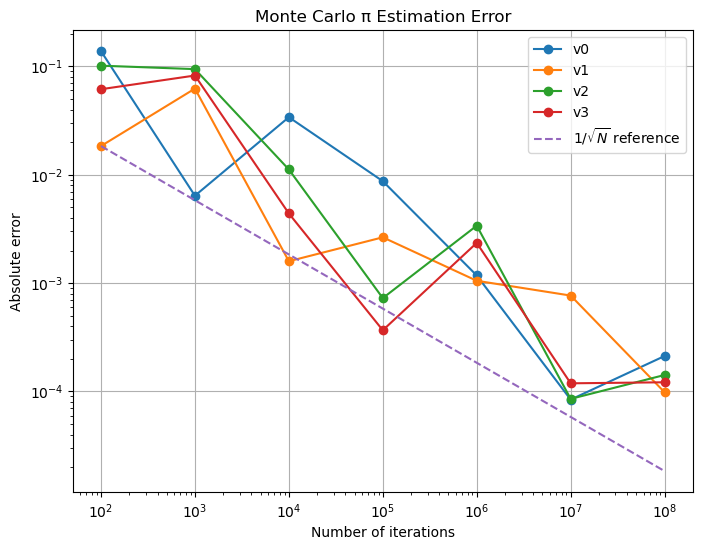

In [11]:
### import random
import math
import time
import numpy as np
import matplotlib.pyplot as plt





# -----------------------------
# Experiment setup
# -----------------------------

iteration_counts = np.logspace(2, 8, 7, dtype=int)

functions = [
     ("v0", compute_pi_baseline_v1),
    ("v1", compute_pi_baseline_v1),
    ("v2", compute_pi_baseline_v2),
    ("v3", compute_pi_baseline_v3),
]

results = {name: [] for name, _ in functions}


# -----------------------------
# Run experiments
# -----------------------------

for N in iteration_counts:

    print(f"Running N = {N:,}")

    for name, func in functions:

        start = time.perf_counter()

        pi_est = func(N)

        elapsed = time.perf_counter() - start

        error = abs(pi_est - math.pi)

        results[name].append(error)

        print(
            f"{name}: "
            f"pi={pi_est:.8f}  "
            f"error={error:.6e}  "
            f"time={elapsed:.3f}s"
        )

    print()


# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(8, 6))

for name in results:
    plt.plot(
        iteration_counts,
        results[name],
        marker="o",
        label=name,
    )

# theoretical slope
theory = 1 / np.sqrt(iteration_counts)
theory *= results["v1"][0] / theory[0]

plt.plot(
    iteration_counts,
    theory,
    "--",
    label=r"$1/\sqrt{N}$ reference",
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Number of iterations")
plt.ylabel("Absolute error")

plt.title("Monte Carlo π Estimation Error")

plt.grid(True)
plt.legend()

plt.show()

In [12]:
%prun -s cumulative compute_pi_baseline_v1(1_000_000)

         2000004 function calls in 0.372 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.372    0.372 {built-in method builtins.exec}
        1    0.000    0.000    0.371    0.371 <string>:1(<module>)
        1    0.292    0.292    0.371    0.371 2720131820.py:25(compute_pi_baseline_v1)
  2000000    0.079    0.000    0.079    0.000 {method 'random' of '_random.Random' objects}
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}

In [6]:
%lprun -f compute_pi_baseline_v1 compute_pi_baseline_v1(1_000_000)

Timer unit: 1e-09 s

Total time: 0.633815 s
File: /tmp/ipykernel_1035810/4115215487.py
Function: compute_pi_baseline_v1 at line 25

Line #      Hits         Time  Per Hit   % Time  Line Contents
    25                                           def compute_pi_baseline_v1(Niter):
    26                                           
    27                                           
    28         1        340.0    340.0      0.0      count=0
    29   1000001   90410826.0     90.4     14.3      for i in range(Niter):
    30   1000000  136559620.0    136.6     21.5          x = random.random()
    31   1000000  124000669.0    124.0     19.6          y = random.random()
    32   1000000  181537280.0    181.5     28.6          if x**2+y**2 < 1:
    33    785606  101304922.0    129.0     16.0              count+=1
    34                                           
    35         1       1292.0   1292.0      0.0      piEst=4*count/Niter
    36                                           
    37      

In [7]:
%memit compute_pi_baseline_v1(1_000_000)

peak memory: 131.99 MiB, increment: 2.13 MiB


N=    10,000   error=1.207e-03   time=0.001s
N=    21,544   error=1.218e-02   time=0.002s
N=    46,415   error=1.153e-02   time=0.005s
N=   100,000   error=2.807e-03   time=0.010s
N=   215,443   error=6.969e-04   time=0.022s
N=   464,158   error=3.454e-03   time=0.049s
N= 1,000,000   error=2.047e-04   time=0.100s
N= 2,154,434   error=2.522e-03   time=0.211s
N= 4,641,588   error=7.802e-04   time=0.469s
N=10,000,000   error=7.425e-05   time=0.978s

Fitted model:
error ≈ 0.479 * N^(-0.459)

Estimated samples needed for error=1e-07:
N ≈ 2.297e+13

Estimated runtime:
2.309e+06 seconds
641.39 hours
26.72 days


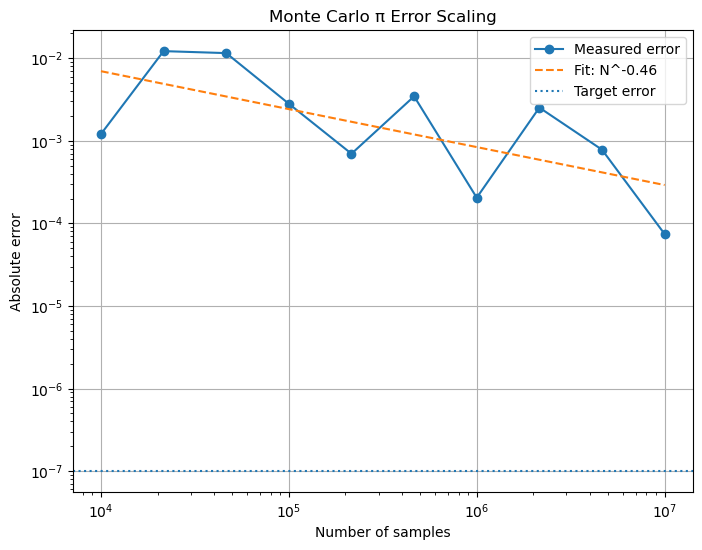

In [13]:
import random
import math
import time
import numpy as np
import matplotlib.pyplot as plt



# ------------------------------------------------
# Collect measurements
# ------------------------------------------------

Ns = np.logspace(4, 7, 10, dtype=int)

errors = []
times = []

for N in Ns:

    start = time.perf_counter()

    pi_est = compute_pi_baseline_v3(N)

    elapsed = time.perf_counter() - start

    error = abs(pi_est - math.pi)

    errors.append(error)
    times.append(elapsed)

    print(
        f"N={N:>10,d}   "
        f"error={error:.3e}   "
        f"time={elapsed:.3f}s"
    )


errors = np.array(errors)
times = np.array(times)


# ------------------------------------------------
# Fit error model:
#
# error ~ C / sqrt(N)
# => log(error) = log(C) - 0.5 log(N)
# ------------------------------------------------

logN = np.log(Ns)
logE = np.log(errors)

slope, intercept = np.polyfit(logN, logE, 1)

C = np.exp(intercept)

print("\nFitted model:")
print(f"error ≈ {C:.3f} * N^({slope:.3f})")


# ------------------------------------------------
# Estimate N needed for target precision
# ------------------------------------------------

target_error = 1e-7

N_required = (C / target_error)**2

print(f"\nEstimated samples needed for error={target_error}:")
print(f"N ≈ {N_required:.3e}")


# ------------------------------------------------
# Fit timing model:
#
# time = k * N
# ------------------------------------------------

k = np.mean(times / Ns)

estimated_time = k * N_required

print(f"\nEstimated runtime:")
print(f"{estimated_time:.3e} seconds")
print(f"{estimated_time/3600:.2f} hours")
print(f"{estimated_time/86400:.2f} days")


# ------------------------------------------------
# Plot
# ------------------------------------------------

plt.figure(figsize=(8,6))

plt.loglog(Ns, errors, "o-", label="Measured error")

fit_curve = C * Ns**slope

plt.loglog(
    Ns,
    fit_curve,
    "--",
    label=f"Fit: N^{slope:.2f}",
)

plt.axhline(
    target_error,
    linestyle=":",
    label="Target error",
)

plt.xlabel("Number of samples")
plt.ylabel("Absolute error")

plt.title("Monte Carlo π Error Scaling")

plt.grid(True)
plt.legend()

plt.show()


Running N = 10,000
  repeat  1: error=1.593e-03   time=0.001s
  repeat  2: error=1.839e-02   time=0.001s
  repeat  3: error=2.921e-02   time=0.001s
  repeat  4: error=2.407e-03   time=0.001s
  repeat  5: error=1.601e-02   time=0.001s
  repeat  6: error=2.793e-03   time=0.001s
  repeat  7: error=5.993e-03   time=0.001s
  repeat  8: error=1.239e-02   time=0.001s
  repeat  9: error=1.879e-02   time=0.001s
  repeat 10: error=2.401e-02   time=0.001s

Running N = 21,544
  repeat  1: error=8.426e-03   time=0.002s
  repeat  2: error=4.385e-03   time=0.002s
  repeat  3: error=2.485e-03   time=0.002s
  repeat  4: error=1.195e-02   time=0.002s
  repeat  5: error=6.717e-04   time=0.002s
  repeat  6: error=6.012e-03   time=0.002s
  repeat  7: error=1.928e-03   time=0.002s
  repeat  8: error=3.828e-03   time=0.002s
  repeat  9: error=3.372e-02   time=0.002s
  repeat 10: error=8.574e-04   time=0.002s

Running N = 46,415
  repeat  1: error=8.209e-03   time=0.005s
  repeat  2: error=3.339e-03   time=0

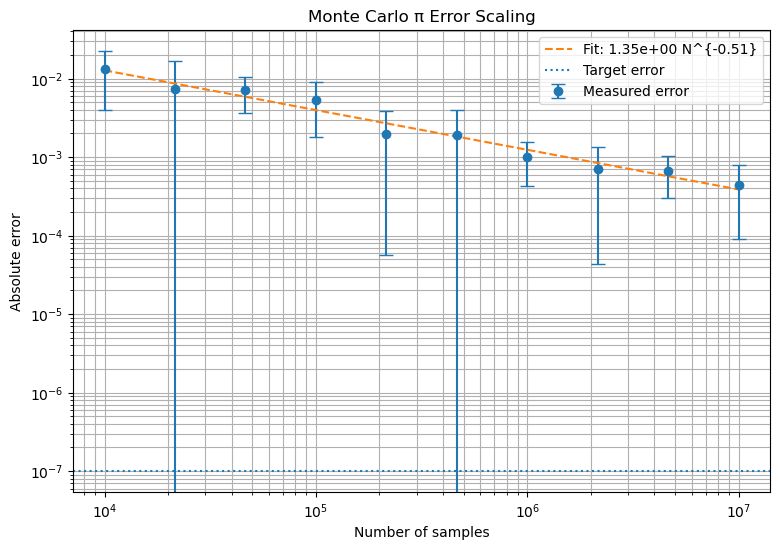

In [10]:
import random
import math
import time
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------
# Baseline implementation
# ------------------------------------------------

def compute_pi_baseline_v1(Niter):

    count = 0

    for _ in range(Niter):

        x = random.random()
        y = random.random()

        if x*x + y*y < 1:
            count += 1

    return 4 * count / Niter


# ------------------------------------------------
# Experiment configuration
# ------------------------------------------------

Ns = np.logspace(4, 7, 10, dtype=int)

n_repeats = 10

mean_errors = []
std_errors = []

mean_times = []
std_times = []


# ------------------------------------------------
# Run experiments
# ------------------------------------------------

for N in Ns:

    errors = []
    runtimes = []

    print(f"\nRunning N = {N:,}")

    for repeat in range(n_repeats):

        start = time.perf_counter()

        pi_est = compute_pi_baseline_v3(N)

        elapsed = time.perf_counter() - start

        error = abs(pi_est - math.pi)

        errors.append(error)
        runtimes.append(elapsed)

        print(
            f"  repeat {repeat+1:2d}: "
            f"error={error:.3e}   "
            f"time={elapsed:.3f}s"
        )

    mean_errors.append(np.mean(errors))
    std_errors.append(np.std(errors))

    mean_times.append(np.mean(runtimes))
    std_times.append(np.std(runtimes))


mean_errors = np.array(mean_errors)
std_errors = np.array(std_errors)

mean_times = np.array(mean_times)
std_times = np.array(std_times)


# ------------------------------------------------
# Fit scaling law
#
# error ~ C * N^alpha
#
# log(error) = log(C) + alpha log(N)
# ------------------------------------------------

logN = np.log(Ns)
logE = np.log(mean_errors)

alpha, intercept = np.polyfit(logN, logE, 1)

C = np.exp(intercept)

print("\n----------------------------------")
print("Fitted scaling law")
print("----------------------------------")

print(f"error ≈ {C:.3e} * N^({alpha:.3f})")

print("\nExpected theoretical slope: -0.5")


# ------------------------------------------------
# Predict required samples
# ------------------------------------------------

target_error = 1e-7

N_required = (target_error / C)**(1 / alpha)

print("\n----------------------------------")
print("Prediction for target precision")
print("----------------------------------")

print(f"Target error : {target_error:.1e}")
print(f"Required N   : {N_required:.3e}")


# ------------------------------------------------
# Fit timing model
#
# time = k * N
# ------------------------------------------------

k = np.mean(mean_times / Ns)

estimated_time = k * N_required

print("\n----------------------------------")
print("Estimated runtime")
print("----------------------------------")

print(f"{estimated_time:.3e} seconds")
print(f"{estimated_time/3600:.2f} hours")
print(f"{estimated_time/86400:.2f} days")


# ------------------------------------------------
# Plot
# ------------------------------------------------

plt.figure(figsize=(9, 6))

plt.errorbar(
    Ns,
    mean_errors,
    yerr=std_errors,
    fmt='o',
    capsize=5,
    label='Measured error',
)

fit_curve = C * Ns**alpha

plt.loglog(
    Ns,
    fit_curve,
    '--',
    label=fr'Fit: {C:.2e} N^{{{alpha:.2f}}}',
)

plt.axhline(
    target_error,
    linestyle=':',
    label='Target error',
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Number of samples")
plt.ylabel("Absolute error")

plt.title("Monte Carlo π Error Scaling")

plt.grid(True, which="both")
plt.legend()

plt.show()

Comments : 440 days to get 7 decimals. Probably a bit less with v2 or v3. 
Let's call that baseline t_baseline 

In [9]:
t_baseline = 81 #days


In [11]:
import numpy as np
from concurrent.futures import ThreadPoolExecutor


def worker(n):
    x = np.random.random(n)
    y = np.random.random(n)
    return np.sum(x*x + y*y < 1.0)


def compute_pi_numpy_threads(N, nthreads=8):

    chunk = N // nthreads

    with ThreadPoolExecutor(max_workers=nthreads) as pool:
        counts = list(pool.map(worker, [chunk]*nthreads))

    count = sum(counts)

    return 4.0 * count / (chunk * nthreads)

In [12]:
%timeit compute_pi_numpy_threads(1_000_000_000,nthreads=64)

9.21 s ± 4.95 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [13]:
%timeit compute_pi_numpy_threads(1_000_000_000,nthreads=16)

9.28 s ± 6.24 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [14]:
import numpy as np
from numba import njit


@njit
def estimate_pi_numba_fast(n_points: int) -> float:

    inside = 0

    for _ in range(n_points):

        x = np.random.random()
        y = np.random.random()

        if x*x + y*y <= 1.0:
            inside += 1

    return 4.0 * inside / n_points

In [15]:
import os 
import numpy as np
import time

N=100000
M=3000

os.environ["OMP_NUM_THREADS"] = "1"


# --- Benchmark 1: Pure Python Loop ---
a = np.random.rand(N)
b = np.random.rand(N)
start = time.time()
c = [a[i] + b[i] for i in range(N)]
end = time.time()
python_loop_time = end - start
print(f"Python loop time: {python_loop_time:.4f} seconds")

# --- Benchmark 2: NumPy Vectorized ---
start = time.time()
c_np = a + b
end = time.time()
numpy_vector_time = end - start
print(f"NumPy vectorized time: {numpy_vector_time:.4f} seconds")

# --- Benchmark 3: Matrix Multiplication ---


A = np.random.rand(M, M)
B = np.random.rand(M, M)
start = time.time()
C = A @ B
end = time.time()
matmul_time = end - start
print(f"Matrix multiplication time: {matmul_time:.4f} seconds")


Python loop time: 0.0131 seconds
NumPy vectorized time: 0.0003 seconds
Matrix multiplication time: 0.0635 seconds


In [16]:
os.environ["OMP_NUM_THREADS"] = "16"



# --- Benchmark 1: Pure Python Loop ---
a = np.random.rand(N)
b = np.random.rand(N)
start = time.time()
c = [a[i] + b[i] for i in range(N)]
end = time.time()
python_loop_time = end - start
print(f"Python loop time: {python_loop_time:.4f} seconds")

# --- Benchmark 2: NumPy Vectorized ---
start = time.time()
c_np = a + b
end = time.time()
numpy_vector_time = end - start
print(f"NumPy vectorized time: {numpy_vector_time:.4f} seconds")

# --- Benchmark 3: Matrix Multiplication ---


A = np.random.rand(M, M)
B = np.random.rand(M, M)
start = time.time()
C = A @ B
end = time.time()
matmul_time = end - start
print(f"Matrix multiplication time: {matmul_time:.4f} seconds")


Python loop time: 0.0137 seconds
NumPy vectorized time: 0.0001 seconds
Matrix multiplication time: 0.0629 seconds


In [15]:
# kernel must be killed to run this.
import time
import sys
import os

verbose=True

# without that line the default chosen by python would be the number of cores actually available in your jupyter session !
os.environ["OMP_NUM_THREADS"] = "4"

nthreads=os.environ['OMP_NUM_THREADS']
#nthreads = 'unknown'
import numpy as np
N = 2000
# Create two large random matrices
a = np.random.randn(N, N)
b = np.random.randn(N)
Mem = (a.nbytes + b.nbytes)


t1 = time.time()
# That's the expensive call:
np.linalg.solve(a, b)
dt1  = time.time() - t1


# matrix vector mult
nrep=100
t2 = time.time()
for i in range(nrep):
    b= a@b

dt2 = (time.time()-t2)/1000

if verbose == True:
    print(f"Number of threads used: {nthreads}")
    print(f"Solving A x = b, with A a ({N},{N}) matrix and b a {N} vector")
    print(f"Memory used {(a.nbytes + b.nbytes)*1e-6}MB")
    print(f"time to solve A x = b {dt1} seconds")
    print(f"Time to 1 matrix vector multiplication {dt2} seconds")

#print("N,nthreads,Mem,linalg time, matrix vector time")
print(f"{N},{nthreads},{Mem},{dt1},{dt2}")
# results dor N=2000
# old                  # new
# 1 core 5.25e-05
# 4 core 1.74e-5       4.5e-6
# ...


Number of threads used: 4
Solving A x = b, with A a (2000,2000) matrix and b a 2000 vector
Memory used 32.016MB
time to solve A x = b 0.12085723876953125 seconds
Time to 1 matrix vector multiplication 4.891157150268555e-06 seconds
2000,4,32016000,0.12085723876953125,4.891157150268555e-06


In [14]:
import time
import numpy as np

from threadpoolctl import threadpool_limits
from threadpoolctl import threadpool_info


# ------------------------------------------------
# Problem size
# ------------------------------------------------

N = 2000

a = np.random.randn(N, N)
b = np.random.randn(N)

Mem = a.nbytes + b.nbytes


# ------------------------------------------------
# Function to benchmark
# ------------------------------------------------

def benchmark(nthreads):

    with threadpool_limits(limits=nthreads):

        # ----------------------------------------
        # Linear solve
        # ----------------------------------------

        t1 = time.time()

        np.linalg.solve(a, b)

        dt1 = time.time() - t1


        # ----------------------------------------
        # Matrix-vector multiply
        # ----------------------------------------

        nrep = 100

        x = b.copy()

        t2 = time.time()

        for _ in range(nrep):
            x = a @ x

        dt2 = (time.time() - t2) / nrep


    print()
    print(f"Threads: {nthreads}")
    print(f"Memory : {Mem*1e-6:.1f} MB")
    print(f"solve   : {dt1:.4f} s")
    print(f"matvec  : {dt2:.6f} s")


# ------------------------------------------------
# Inspect backend
# ------------------------------------------------

print(threadpool_info())


# ------------------------------------------------
# Test different thread counts
# ------------------------------------------------

for nthreads in [1, 2, 4, 8, 16, 32, 64]:

    benchmark(nthreads)

[{'user_api': 'blas', 'internal_api': 'openblas', 'num_threads': 16, 'prefix': 'libopenblas', 'filepath': '/scratch/cicd/jenkins/workspace/UoP-Spack/main/293/spack/opt/spack/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder___/linux-rhel8-zen4/gcc-13.3.1/openblas-0.3.30-k7rfcfy55jybtoth4dltypm7bgdc2a7t/lib/libopenblasp-r0.3.30.so', 'version': '0.3.30', 'threading_layer': 'openmp', 'architecture': 'Cooperlake'}, {'user_api': 'openmp', 'internal_api': 'openmp', 'num_threads': 16, 'prefix': 'libgomp', 'filepath': '/scratch/cicd/jenkins/workspace/UoP-Spack/main/293/spack/opt/spack/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder___/linux-rhel8-zen4/none-none/gcc-runtime-13.3.1-cx24j3u7ib2qpyf4ymz6iwewzc3ferjv/lib/libgom

In [5]:
import sys
import numpy as np
import numba
#np.show_config()


print("Python :", sys.executable)
print("NumPy  :", np.__version__)
print("NumPy path :", np.__file__)
print("Numba  :", numba.__version__)
print("Numba path :", numba.__file__)

Python : /users/vdrach/HPC_pi/bin/python
NumPy  : 1.26.4
NumPy path : /scratch/cicd/jenkins/workspace/UoP-Spack/main/212/spack/opt/spack/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder___/linux-rhel8-zen4/gcc-13.3.1/py-numpy-1.26.4-k5adanvkb7spnqjhkcfj25hvfgveixjs/lib/python3.11/site-packages/numpy/__init__.py
Numba  : 0.59.1
Numba path : /scratch/cicd/jenkins/workspace/UoP-Spack/main/212/spack/opt/spack/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder___/linux-rhel8-zen4/gcc-13.3.1/py-numba-0.59.1-lmrlnavhmio2q5cb5qcdjpb5q636qhid/lib/python3.11/site-packages/numba/__init__.py


In [6]:
import numpy as np
np.show_config()

{
  "Compilers": {
    "c": {
      "name": "gcc",
      "linker": "ld.bfd",
      "version": "13.3.1",
      "commands": "/scratch/cicd/jenkins/workspace/UoP-Spack/main/212/spack/opt/spack/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder___/linux-rhel8-zen4/none-none/compiler-wrapper-1.0-vh5cgzh2isqvehuirlkkynf2a4gh2f6a/libexec/spack/gcc/gcc"
    },
    "cython": {
      "name": "cython",
      "linker": "cython",
      "version": "3.1.3",
      "commands": "cython"
    },
    "c++": {
      "name": "gcc",
      "linker": "ld.bfd",
      "version": "13.3.1",
      "commands": "/scratch/cicd/jenkins/workspace/UoP-Spack/main/212/spack/opt/spack/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder___/linux-rhel8-zen4/non

/scratch/cicd/jenkins/workspace/UoP-Spack/main/212/spack/opt/spack/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder___/linux-rhel8-zen4/gcc-13.3.1/py-numpy-1.26.4-k5adanvkb7spnqjhkcfj25hvfgveixjs/lib/python3.11/site-packages/numpy/__config__.py:155: UserWarning: Install `pyyaml` for better output
  warnings.warn("Install `pyyaml` for better output", stacklevel=1)


In [1]:

import random
import numpy as np

from numba import njit, prange, cuda


# ============================================================
# 1. BASELINE PYTHON
# ============================================================

def compute_pi_baseline_v3(Niter):

    rng = random.random

    count = 0

    for i in range(Niter):

        x = rng()
        y = rng()

        if x*x + y*y < 1.0:
            count += 1

    piEst = 4.0 * count / Niter

    return piEst


# ============================================================
# 2. NUMBA NJIT (nopython=True)
# ============================================================

@njit
def compute_pi_numba_njit(Niter):

    count = 0

    for i in range(Niter):

        x = np.random.random()
        y = np.random.random()

        if x*x + y*y < 1.0:
            count += 1

    piEst = 4.0 * count / Niter

    return piEst


# ============================================================
# 3. NUMBA OBJECT MODE (nopython=False)
# ============================================================

@njit(nopython=False)
def compute_pi_numba_object_mode(Niter):

    rng = random.random

    count = 0

    for i in range(Niter):

        x = rng()
        y = rng()

        if x*x + y*y < 1.0:
            count += 1

    piEst = 4.0 * count / Niter

    return piEst


# ============================================================
# 4. NUMBA PARALLEL CPU
# ============================================================

@njit(parallel=True)
def compute_pi_numba_parallel(Niter):

    count = 0

    for i in prange(Niter):

        x = np.random.random()
        y = np.random.random()

        if x*x + y*y < 1.0:
            count += 1

    piEst = 4.0 * count / Niter

    return piEst


# ============================================================
# 5. NUMBA CUDA GPU
# ============================================================

@cuda.jit
def compute_pi_cuda_kernel(rng_states, results):

    idx = cuda.grid(1)

    if idx < results.size:

        # xoroshiro random numbers
        x = cuda.random.xoroshiro128p_uniform_float32(rng_states, idx)
        y = cuda.random.xoroshiro128p_uniform_float32(rng_states, idx)

        if x*x + y*y < 1.0:
            results[idx] = 1
        else:
            results[idx] = 0


def compute_pi_numba_cuda(Niter):

    from numba.cuda.random import (
        create_xoroshiro128p_states
    )

    threads_per_block = 256
    blocks = (Niter + threads_per_block - 1) // threads_per_block

    rng_states = create_xoroshiro128p_states(
        threads_per_block * blocks,
        seed=42
    )

    results = np.zeros(Niter, dtype=np.int32)

    d_results = cuda.to_device(results)

    compute_pi_cuda_kernel[blocks, threads_per_block](
        rng_states,
        d_results
    )

    results = d_results.copy_to_host()

    count = results.sum()

    piEst = 4.0 * count / Niter

    return piEst

# ============================================================
# 6. PURE NUMPY VECTORIZED VERSION
# ============================================================

def compute_pi_numpy(Niter):

    x = np.random.random(Niter)
    y = np.random.random(Niter)

    inside = (x*x + y*y) < 1.0

    count = np.sum(inside)

    piEst = 4.0 * count / Niter

    return piEst


# ============================================================
# 7. NUMPY + NUMBA
# ============================================================

@njit
def compute_pi_numpy_numba_kernel(x, y):

    count = 0

    for i in range(x.size):

        if x[i]*x[i] + y[i]*y[i] < 1.0:
            count += 1

    return count


def compute_pi_numpy_numba(Niter):

    # NumPy generates vectors
    x = np.random.random(Niter)
    y = np.random.random(Niter)

    # Numba accelerates the loop
    count = compute_pi_numpy_numba_kernel(x, y)

    piEst = 4.0 * count / Niter

    return piEst


# ============================================================
# 8. NUMPY + NUMBA PARALLEL
# ============================================================

@njit(parallel=True)
def compute_pi_numpy_numba_parallel_kernel(x, y):

    count = 0

    for i in prange(x.size):

        if x[i]*x[i] + y[i]*y[i] < 1.0:
            count += 1

    return count


def compute_pi_numpy_numba_parallel(Niter):

    x = np.random.random(Niter)
    y = np.random.random(Niter)

    count = compute_pi_numpy_numba_parallel_kernel(x, y)

    piEst = 4.0 * count / Niter

    return piEst


@njit
def compute_pi_numpy_numba2(Niter):

    x = np.random.random(Niter)
    y = np.random.random(Niter)

    inside = (x*x + y*y) < 1.0

    count = np.sum(inside)

    piEst = 4.0 * count / Niter

    return piEst



compute_pi_numpy_numba2(10)

/scratch/cicd/jenkins/workspace/UoP-Spack/main/212/spack/opt/spack/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder___/linux-rhel8-zen4/gcc-13.3.1/py-numba-0.59.1-lmrlnavhmio2q5cb5qcdjpb5q636qhid/lib/python3.11/site-packages/numba/core/decorators.py:250: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


3.2

In [2]:
N = 5_000_000
compute_pi_numba_njit(10)
compute_pi_numba_object_mode(10)   # compile
compute_pi_numba_parallel(10)   # compile
compute_pi_numpy_numba_parallel(10)

%timeit compute_pi_baseline_v3(N)
%timeit compute_pi_numpy(N)
%timeit compute_pi_numba_njit(N)
%timeit compute_pi_numba_object_mode(N)
%timeit compute_pi_numba_parallel(N)
%timeit compute_pi_numpy_numba(N)
%timeit compute_pi_numpy_numba_parallel(N)

450 ms ± 16.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
61.3 ms ± 82 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
25.6 ms ± 32.4 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
25.5 ms ± 16.2 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
1.63 ms ± 12.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
47.3 ms ± 26.7 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
49.8 ms ± 172 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


old results :
85 ms ± 331 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)

9.02 ms ± 9 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

5.11 ms ± 5.69 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

5.12 ms ± 3.25 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

100 μs ± 656 ns per loop (mean ± std. dev. of 7 runs, 100 loops each)

8.14 ms ± 70.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

23.4 ms ± 802 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)

In [23]:
compute_pi_numba_cuda(10)
%timeit compute_pi_numba_cuda(N)

CudaSupportError: Error at driver init: 
Call to cuInit results in CUDA_ERROR_STUB_LIBRARY (34):

old res :184 ms ± 14.6 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

In [1]:
import numpy as np


def laplacian_numpy(u):

    return (
          u[2:, 1:-1]
        + u[:-2, 1:-1]
        + u[1:-1, 2:]
        + u[1:-1, :-2]
        - 4.0 * u[1:-1, 1:-1]
    )



import numpy as np
from numba import njit


@njit
def laplacian_numba(u):

    nx, ny = u.shape

    out = np.empty((nx-2, ny-2), dtype=u.dtype)

    for i in range(1, nx-1):

        for j in range(1, ny-1):

            out[i-1, j-1] = (
                  u[i+1, j]
                + u[i-1, j]
                + u[i, j+1]
                + u[i, j-1]
                - 4.0 * u[i, j]
            )

    return out



from numba import njit, prange


@njit(parallel=True)
def laplacian_numba_parallel(u):

    nx, ny = u.shape

    out = np.empty((nx-2, ny-2), dtype=u.dtype)

    for i in prange(1, nx-1):

        for j in range(1, ny-1):

            out[i-1, j-1] = (
                  u[i+1, j]
                + u[i-1, j]
                + u[i, j+1]
                + u[i, j-1]
                - 4.0 * u[i, j]
            )

    return out


from numba import cuda


# ============================================================
# CUDA LAPLACIAN KERNEL
# ============================================================

@cuda.jit
def laplacian_cuda_kernel(u, out):

    i, j = cuda.grid(2)

    nx, ny = u.shape

    if 1 <= i < nx-1 and 1 <= j < ny-1:

        out[i, j] = (
              u[i+1, j]
            + u[i-1, j]
            + u[i, j+1]
            + u[i, j-1]
            - 4.0 * u[i, j]
        )


# ============================================================
# DRIVER FUNCTION
# ============================================================

def laplacian_cuda(u):

    nx, ny = u.shape

    out = np.zeros_like(u)

    # Copy to GPU
    d_u = cuda.to_device(u)
    d_out = cuda.to_device(out)

    # 2D thread block
    threadsperblock = (16, 16)

    blockspergrid_x = (nx + threadsperblock[0] - 1) // threadsperblock[0]
    blockspergrid_y = (ny + threadsperblock[1] - 1) // threadsperblock[1]

    blockspergrid = (blockspergrid_x, blockspergrid_y)
    
    #print("threadsperblock =", threadsperblock)
    #print("blockspergrid   =", blockspergrid)
    #print("total blocks    =", blockspergrid[0] * blockspergrid[1])

    # Launch kernel
    laplacian_cuda_kernel[blockspergrid, threadsperblock](
        d_u,
        d_out
    )

    # Copy back
    out = d_out.copy_to_host()

    return out


def laplacian_cuda_persistent(u, nsteps=100):

    u = np.ascontiguousarray(u)

    nx, ny = u.shape

    d_u = cuda.to_device(u)
    d_out = cuda.device_array_like(u)

    threadsperblock = (16, 16)

    blockspergrid = (
        (nx + 15) // 16,
        (ny + 15) // 16
    )

    for _ in range(nsteps):

        laplacian_cuda_kernel[
            blockspergrid,
            threadsperblock
        ](d_u, d_out)

        d_u, d_out = d_out, d_u

    return d_u.copy_to_host()



In [2]:

import numpy as np

# Large test array
N = 4096

u = np.random.random((N, N))


# ------------------------------------------------------------
# Warmup / compilation
# ------------------------------------------------------------

laplacian_numba(u[:10, :10])
laplacian_numba_parallel(u[:10, :10])

laplacian_cuda(np.ascontiguousarray(u[:10, :10]))
laplacian_cuda_persistent(np.ascontiguousarray(u[:10, :10]))


# ------------------------------------------------------------
# Benchmarks
# ------------------------------------------------------------

%timeit laplacian_numpy(u)

%timeit laplacian_numba(u)

%timeit laplacian_numba_parallel(u)

%timeit laplacian_cuda(u)

%timeit laplacian_cuda_persistent(u)

CudaSupportError: Error at driver init: Call to cuInit results in CUDA_ERROR_STUB_LIBRARY (34)

In [26]:

import numpy as np

# Large test array
N = 4096

u = np.random.random((N, N))


# ------------------------------------------------------------
# Warmup / compilation
# ------------------------------------------------------------

laplacian_numba(u[:10, :10])
laplacian_numba_parallel(u[:10, :10])

laplacian_cuda(np.ascontiguousarray(u[:10, :10]))


# ------------------------------------------------------------
# Benchmarks
# ------------------------------------------------------------

%timeit laplacian_numpy(u)

%timeit laplacian_numba(u)

%timeit laplacian_numba_parallel(u)

%timeit laplacian_cuda(u)

CudaSupportError: Error at driver init: 
Call to cuInit results in CUDA_ERROR_STUB_LIBRARY (34):

GPU version is not great. Can we do better ?



In [2]:

import cupy as cp


def laplacian_cupy(u):

    return (
          u[2:, 1:-1]
        + u[:-2, 1:-1]
        + u[1:-1, 2:]
        + u[1:-1, :-2]
        - 4.0 * u[1:-1, 1:-1]
    )

import numpy as np

# Large test array
N = 4096

u = np.random.random((N, N))


# ------------------------------------------------------------
# Warmup / compilation
# ------------------------------------------------------------

laplacian_cupy(u[:10, :10])

laplacian_cupy(np.ascontiguousarray(u[:10, :10]))


# ------------------------------------------------------------
# Benchmarks
# ------------------------------------------------------------

%timeit laplacian_cupy(u)


75.8 ms ± 29.2 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [2]:
import numpy as np
import jax
import jax.numpy as jnp


# ============================================================
# JAX LAPLACIAN
# ============================================================

@jax.jit
def laplacian_jax(u):

    return (
          u[2:, 1:-1]
        + u[:-2, 1:-1]
        + u[1:-1, 2:]
        + u[1:-1, :-2]
        - 4.0 * u[1:-1, 1:-1]
    )


# Large test array
N = 4096

u = np.random.random((N, N))


# ------------------------------------------------------------
# Warmup / compilation
# ------------------------------------------------------------

laplacian_jax(u[:10, :10])

laplacian_jax(np.ascontiguousarray(u[:10, :10]))


# ------------------------------------------------------------
# Benchmarks
# ------------------------------------------------------------

%timeit laplacian_jax(u)


'+ptx84' is not a recognized feature for this target (ignoring feature)
'+ptx84' is not a recognized feature for this target (ignoring feature)
'+ptx84' is not a recognized feature for this target (ignoring feature)
'+ptx84' is not a recognized feature for this target (ignoring feature)
'+ptx84' is not a recognized feature for this target (ignoring feature)
'+ptx84' is not a recognized feature for this target (ignoring feature)


12.7 ms ± 8.9 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [29]:
%timeit compute_pi_numba_parallel(1_000_000_000)
# 326 ms on GPU for Niter = 1_000_000_000 (how many cores by default ?). For a target stat of 250 000 000 000 000, it would take 22hours.
# full CPU node 85 ms for Niter = 1_000_000_000.For a target stat of 250 000 000 000 000, it would take 5.9 hours.


322 ms ± 145 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [30]:
for _ in range(10):
    pi_est  = compute_pi_numba_parallel(1_000_000_000)
    print(f"{abs(pi_est - math.pi)}")

2.5102410206923054e-05
2.9674410206848023e-05
3.783041020666289e-05
5.320958979293522e-05
0.0001035495897929728
4.362241020672286e-05
2.8441589793093414e-05
1.3622410206970414e-05
1.7384102068973561e-06
6.649358979293751e-05
